### Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

##### 1. Read the data

In [2]:
data_orig = pd.read_csv('../../datasets/data_clean.csv')

##### 2. Examine the data

In [3]:
data_orig.shape

(158, 9)

In [4]:
data_orig.columns

Index(['Ozone', 'Solar.R', 'Wind', 'Temp C', 'Month', 'Day', 'Year', 'Temp',
       'Weather'],
      dtype='object')

In [5]:
data_orig.index

RangeIndex(start=0, stop=158, step=1)

In [6]:
data_orig.head(3)

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
0,41.0,190.0,7.4,67,5,1,2010,67,S
1,36.0,118.0,8.0,72,5,2,2010,72,C
2,12.0,149.0,12.6,74,5,3,2010,74,PS


In [7]:
data_orig.tail(3)

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
155,NaN,145.0,13.2,77,9,27,2010,77,S
156,14.0,191.0,14.3,75,9,28,2010,75,S
157,18.0,131.0,8.0,76,9,29,2010,76,C


In [8]:
data_orig.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ozone    120 non-null    float64
 1   Solar.R  151 non-null    float64
 2   Wind     158 non-null    float64
 3   Temp C   158 non-null    object 
 4   Month    158 non-null    object 
 5   Day      158 non-null    int64  
 6   Year     158 non-null    int64  
 7   Temp     158 non-null    int64  
 8   Weather  155 non-null    object 
dtypes: float64(3), int64(3), object(3)
memory usage: 11.2+ KB


In [9]:
data_orig.describe()

,Ozone,Solar.R,Wind,Day,Year,Temp
count,120.000000,151.000000,158.000000,158.000000,158.0,158.000000
mean,41.583333,185.403974,9.957595,16.006329,2010.0,77.727848
std,32.620709,88.723103,3.511261,8.997166,0.0,9.377877
min,1.000000,7.000000,1.700000,1.000000,2010.0,56.000000
25%,18.000000,119.000000,7.400000,8.000000,2010.0,72.000000
50%,30.500000,197.000000,9.700000,16.000000,2010.0,78.500000
75%,61.500000,257.000000,11.875000,24.000000,2010.0,84.000000
max,168.000000,334.000000,20.700000,31.000000,2010.0,97.000000


###### Take a backup of the original data

In [10]:
data = data_orig.copy()

##### 2. Correct the datatypes

In [11]:
data['Temp C'] =  pd.to_numeric(data['Temp C'], errors='coerce')
data['Month'] = pd.to_numeric(data['Month'], errors='coerce')
data['Weather'] = data['Weather'].astype('category')

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 158 entries, 0 to 157
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   Ozone    120 non-null    float64 
 1   Solar.R  151 non-null    float64 
 2   Wind     158 non-null    float64 
 3   Temp C   157 non-null    float64 
 4   Month    157 non-null    float64 
 5   Day      158 non-null    int64   
 6   Year     158 non-null    int64   
 7   Temp     158 non-null    int64   
 8   Weather  155 non-null    category
dtypes: category(1), float64(5), int64(3)
memory usage: 10.3 KB


##### 3. Remove unwanted columns

In [13]:
data[data['Temp C'] != data['Temp']]

,Ozone,Solar.R,Wind,Temp C,Month,Day,Year,Temp,Weather
10,7.0,NaN,6.9,NaN,5.0,11,2010,74,C


In [14]:
data.drop('Temp C', axis=1, inplace=True)

In [15]:
data['Year'].nunique()

1

In [16]:
data['Year'].unique()

array([2010])

In [17]:
data.drop('Year',axis=1,inplace=True)

In [18]:
data.rename(columns={'Solar.R':'Solar'}, inplace=True)

In [19]:
data.head(3)

,Ozone,Solar,Wind,Month,Day,Temp,Weather
0,41.0,190.0,7.4,5.0,1,67,S
1,36.0,118.0,8.0,5.0,2,72,C
2,12.0,149.0,12.6,5.0,3,74,PS


###### Take a backup - Data contains all proper columns

In [20]:
data1 = data.copy()

##### 4. Check for duplicates

In [21]:
data.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
153    False
154    False
155    False
156     True
157    False
Length: 158, dtype: bool

In [22]:
data[data.duplicated()]

,Ozone,Solar,Wind,Month,Day,Temp,Weather
156,14.0,191.0,14.3,9.0,28,75,S


In [23]:
data.drop_duplicates(inplace=True)

##### 5. Handle null values

In [24]:
data.isnull().sum()

Ozone      38
Solar       7
Wind        0
Month       1
Day         0
Temp        0
Weather     3
dtype: int64

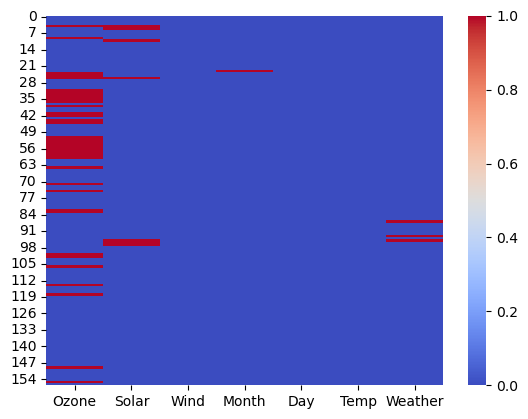

In [25]:
#cols = ['orange','white']
sns.heatmap(data.isnull(), cmap='coolwarm')
plt.show()

###### Replace null values

In [26]:
ozone_avg = np.round(data['Ozone'].mean(),1)
solar_avg =  np.round(data['Solar'].mean(),1)

In [27]:
data['Weather'].mode()

0    S
Name: Weather, dtype: category
Categories (3, object): ['C', 'PS', 'S']

In [28]:
weather_mode = data['Weather'].mode()[0]

In [29]:
ozone_avg,solar_avg,weather_mode

(41.8, 185.4, 'S')

In [30]:
data.fillna({'Ozone':ozone_avg,
             'Solar':solar_avg,
             'Weather':weather_mode
            }, inplace=True)

In [31]:
data.isnull().sum()

Ozone      0
Solar      0
Wind       0
Month      1
Day        0
Temp       0
Weather    0
dtype: int64

In [32]:
data.dropna(inplace=True)

In [33]:
data3 = data.copy()

##### 6. Handle Outliers

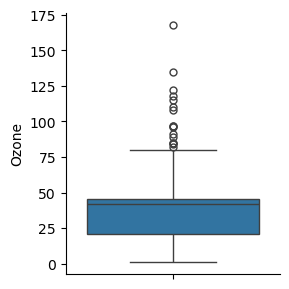

In [34]:
sns.catplot(data['Ozone'], kind='box', height=3)
plt.show()

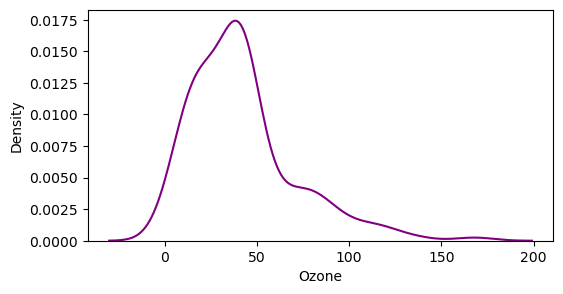

In [35]:
plt.figure(figsize=(6,3))
sns.kdeplot(data['Ozone'], color='purple')
plt.show()

In [36]:
data['Ozone'].describe()

count    156.000000
mean      41.874359
std       28.484864
min        1.000000
25%       21.000000
50%       41.800000
75%       45.250000
max      168.000000
Name: Ozone, dtype: float64

In [37]:
Q1 = data['Ozone'].quantile(0.25)
Q3 = data['Ozone'].quantile(0.75)
IQR = Q3 - Q1
Q1, Q3, IQR

(21.0, 45.25, 24.25)

In [38]:
upper_limit = Q3 + 1.5 * IQR
upper_limit

81.625

In [39]:
data[data['Ozone'] > upper_limit]

,Ozone,Solar,Wind,Month,Day,Temp,Weather
29,115.0,223.0,5.7,5.0,30,79,C
61,135.0,269.0,4.1,7.0,1,84,S
68,97.0,267.0,6.3,7.0,8,92,PS
69,97.0,272.0,5.7,7.0,9,92,C
70,85.0,175.0,7.4,7.0,10,89,PS
85,108.0,223.0,8.0,7.0,25,85,PS
88,82.0,213.0,7.4,7.0,28,88,S
98,122.0,255.0,4.0,8.0,7,89,C
99,89.0,229.0,10.3,8.0,8,90,PS
100,110.0,207.0,8.0,8.0,9,90,C


In [40]:
data['Ozone'] = np.where(data['Ozone'] > upper_limit, upper_limit, data['Ozone'] )

In [41]:
data[data['Ozone'] > upper_limit]

,Ozone,Solar,Wind,Month,Day,Temp,Weather


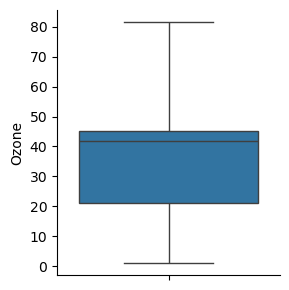

In [42]:
sns.catplot(data['Ozone'], kind='box', height=3)
plt.show()

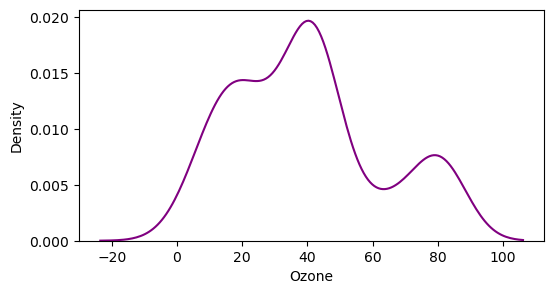

In [43]:
plt.figure(figsize=(6,3))
sns.kdeplot(data['Ozone'], color='purple')
plt.show()

##### 7. Correlation Analysis

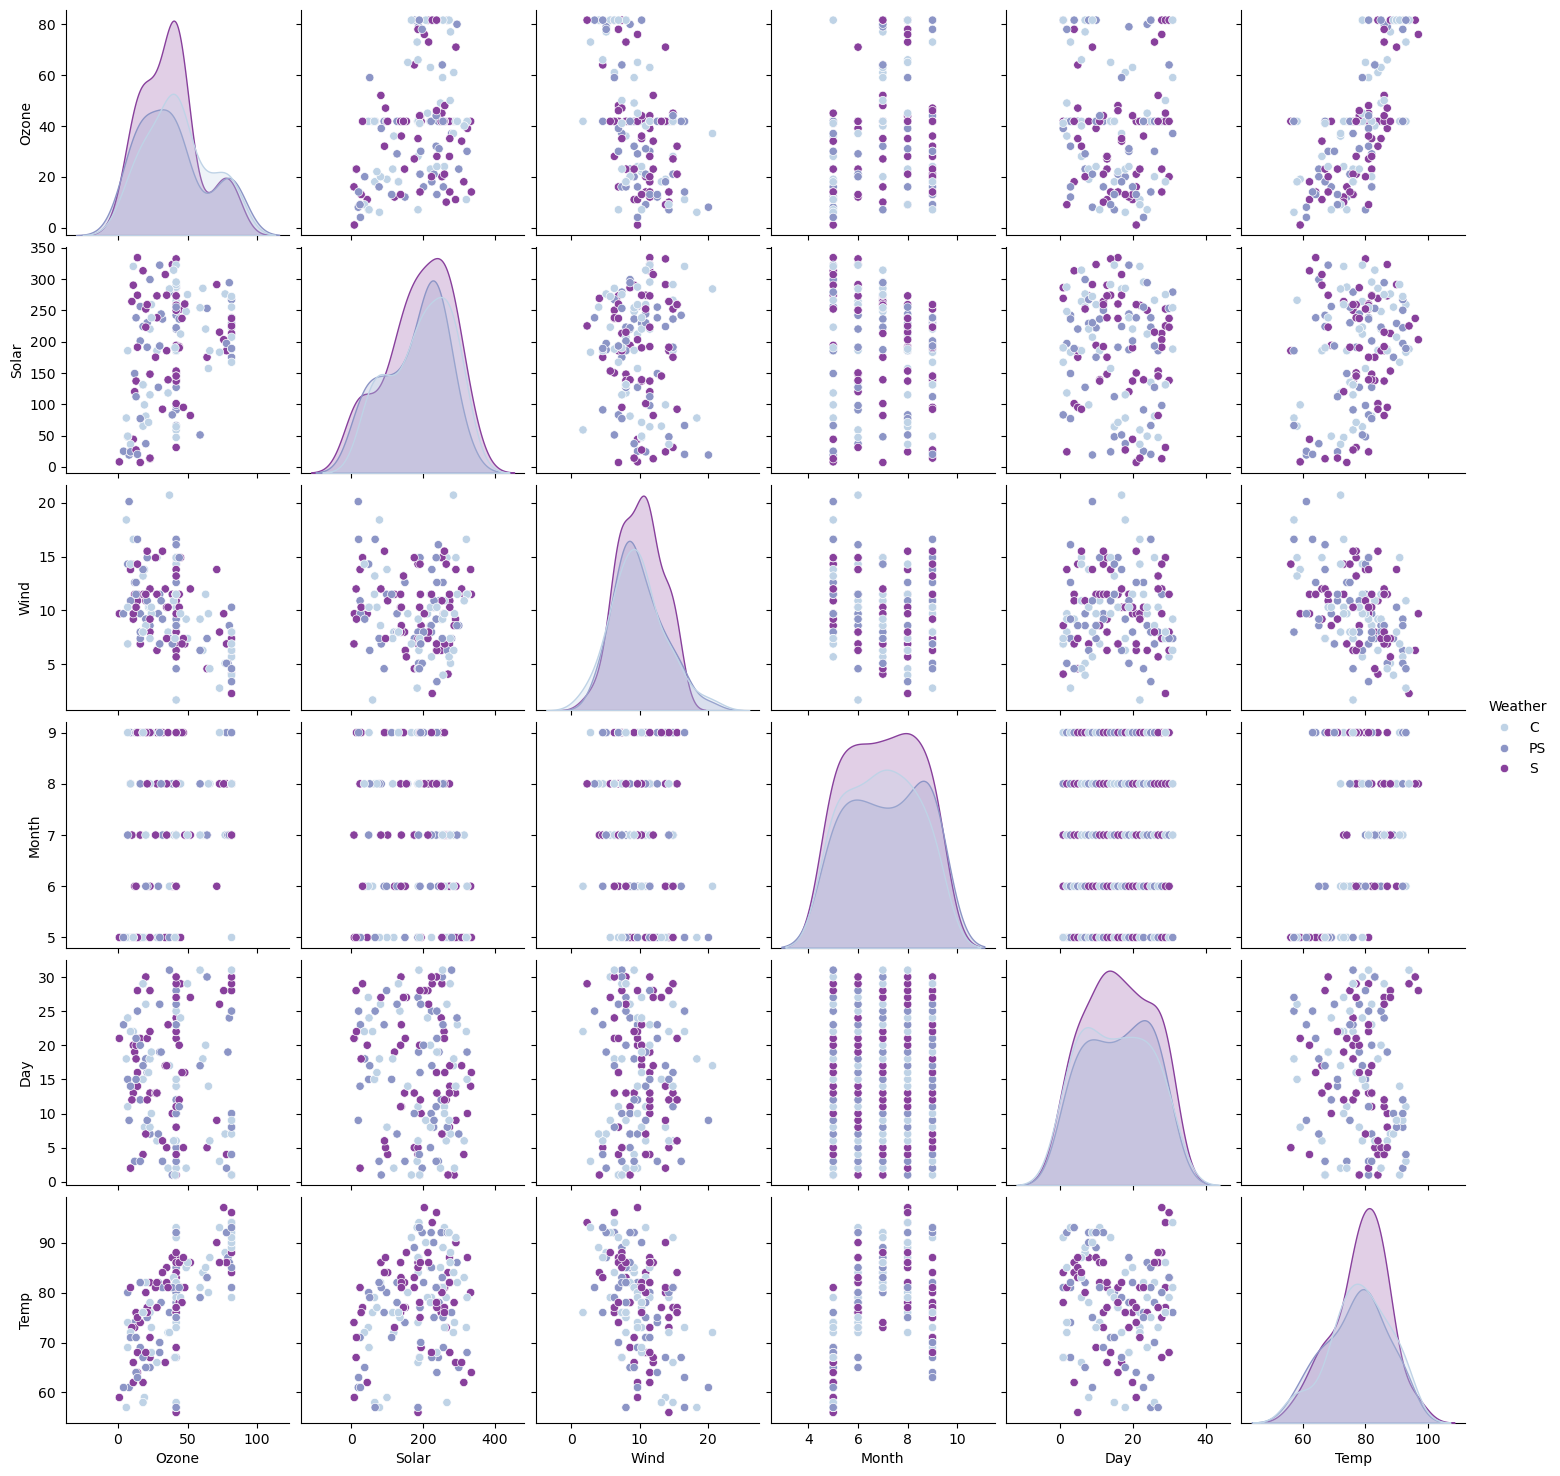

In [52]:
sns.pairplot(data, 
             palette='BuPu', 
             hue='Weather'
            )
plt.show()

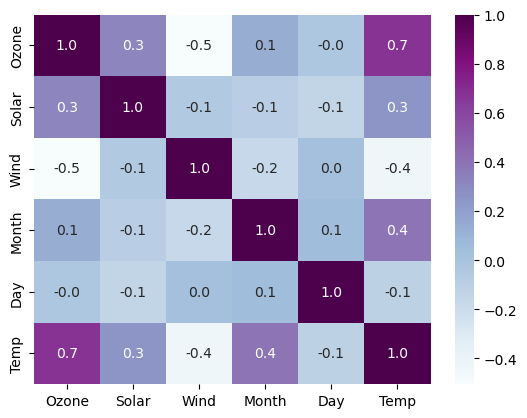

In [50]:
correlations = data._get_numeric_data().corr()
sns.heatmap(correlations, cmap='BuPu', 
            annot=True,
            fmt='0.1f'
           )
plt.show()